In [1]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2





In [2]:
# 1. LOAD DATA
crabdata = pd.read_csv('CrabAgePrediction.csv') 

In [3]:
crabdata.head()

,Sex,Length,Diameter,Height,Weight,Shucked Weight,Viscera Weight,Shell Weight,Age
0,F,1.4375,1.1750,0.4125,24.635715,12.332033,5.584852,6.747181,9
1,M,0.8875,0.6500,0.2125,5.400580,2.296310,1.374951,1.559222,6
2,I,1.0375,0.7750,0.2500,7.952035,3.231843,1.601747,2.764076,6
3,F,1.1750,0.8875,0.2500,13.480187,4.748541,2.282135,5.244657,10
4,I,0.8875,0.6625,0.2125,6.903103,3.458639,1.488349,1.700970,6


In [4]:
crabdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3893 entries, 0 to 3892
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             3893 non-null   object 
 1   Length          3893 non-null   float64
 2   Diameter        3893 non-null   float64
 3   Height          3893 non-null   float64
 4   Weight          3893 non-null   float64
 5   Shucked Weight  3893 non-null   float64
 6   Viscera Weight  3893 non-null   float64
 7   Shell Weight    3893 non-null   float64
 8   Age             3893 non-null   int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 273.9+ KB


In [5]:
#remove height=0
crabdata = crabdata[crabdata['Height'] > 0]

In [6]:
print(crabdata.shape)

(3891, 9)


In [8]:
print(crabdata.duplicated().sum())

0


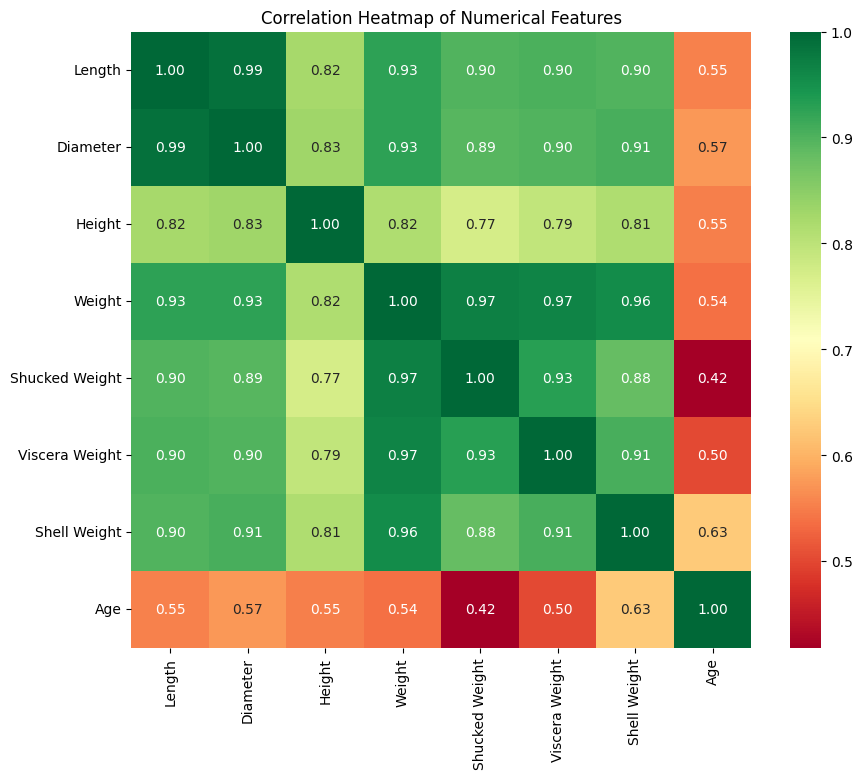

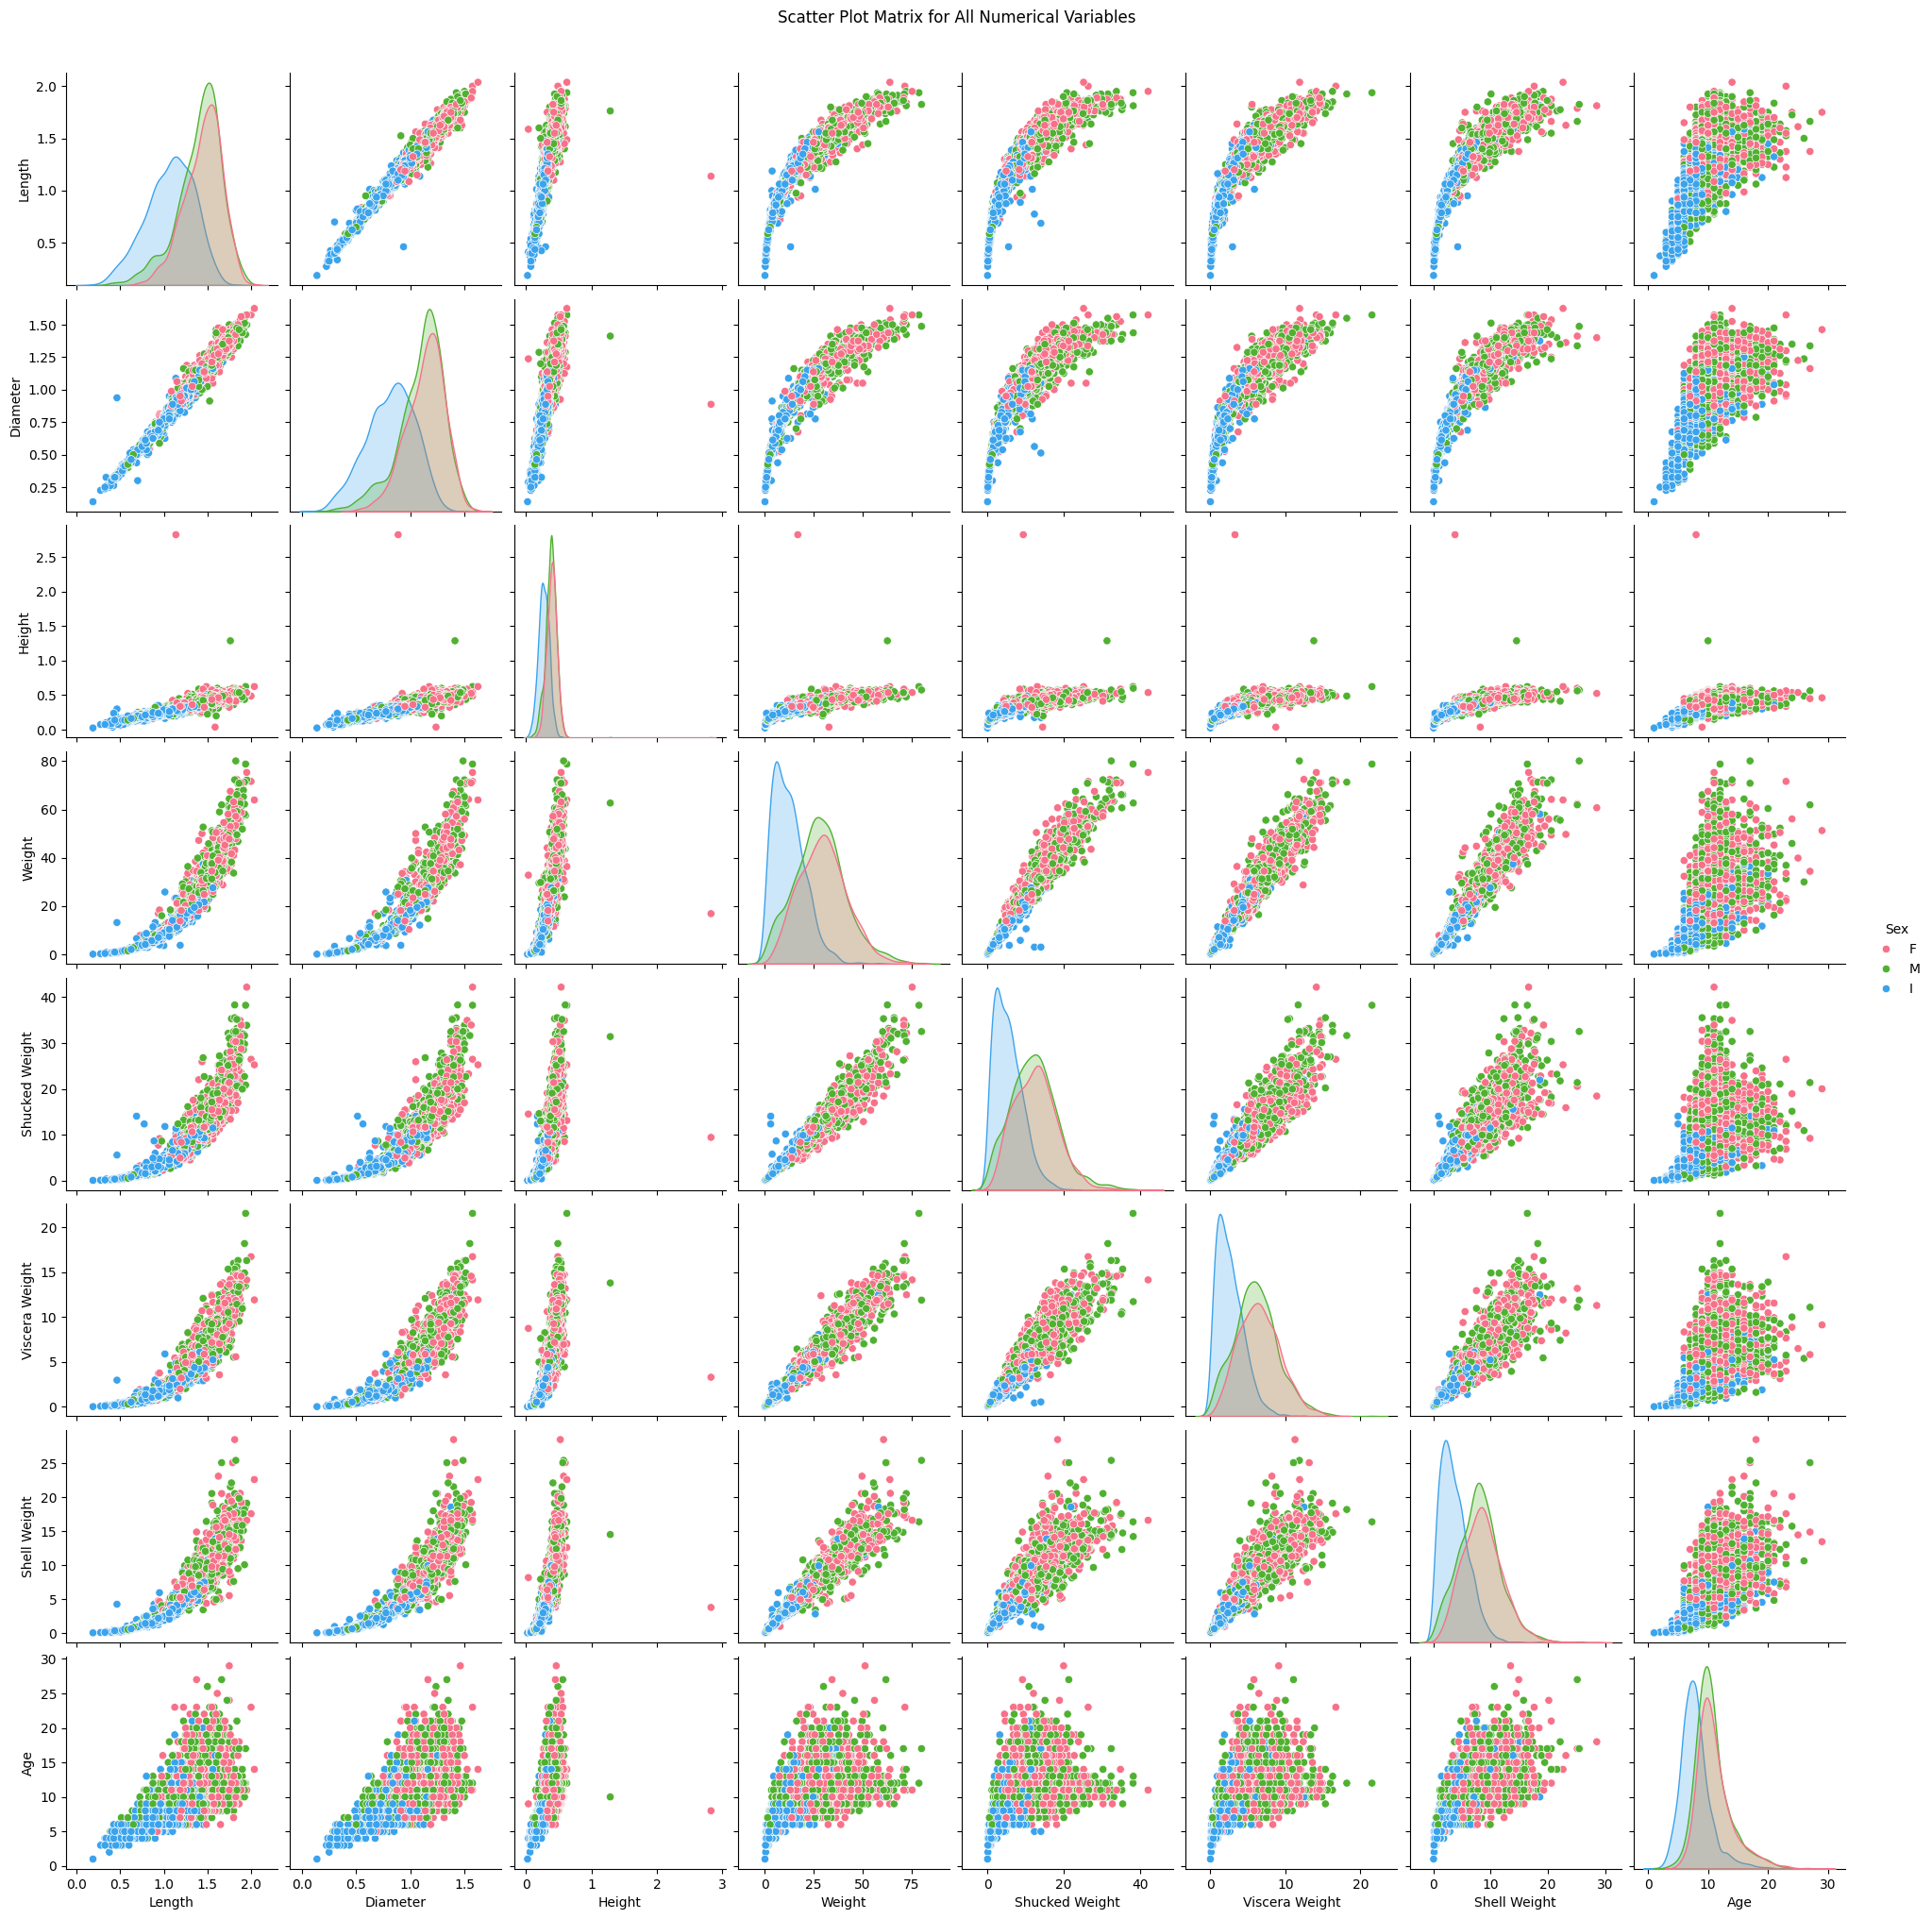

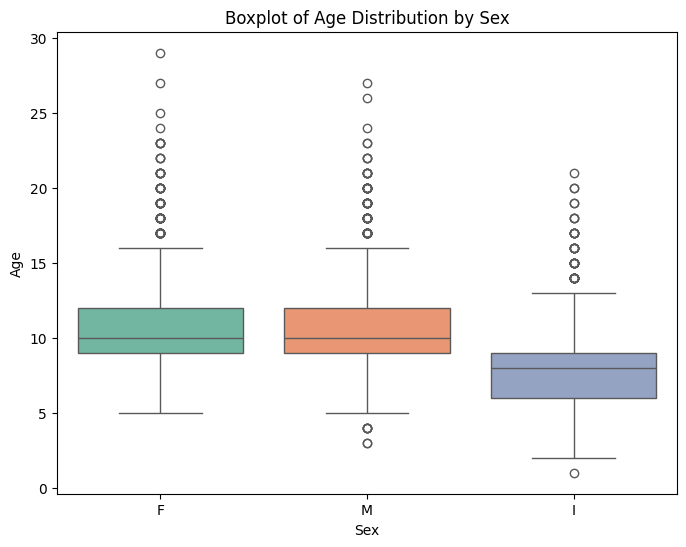

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Correlation Heatmap ---
# We select only numerical columns as 'Sex' cannot be correlated directly
plt.figure(figsize=(10, 8))
numeric_cols = crabdata.select_dtypes(include=['number'])
correlation_matrix = numeric_cols.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

# --- 2. Scatter Plot Matrix (Numerical Variables) ---
# Pairplot creates scatter plots for every combination of numerical variables.
# Using hue='Sex' colors the points to show differences between F, M, and I.
sns.pairplot(crabdata, hue='Sex', diag_kind='kde', palette='husl')
plt.suptitle('Scatter Plot Matrix for All Numerical Variables', y=1.02)
plt.show()

# --- 3. Boxplot by Sex ---
# Useful for seeing the distribution of Age (or other metrics) across Sex categories
plt.figure(figsize=(8, 6))
sns.boxplot(data=crabdata, x='Sex', y='Age', palette='Set2')
plt.title('Boxplot of Age Distribution by Sex')
plt.show()

In [15]:
#data on different scales. so we standardize
from sklearn.preprocessing import StandardScaler
#split data to features and label by making a copy of each
X=crabdata[["Sex","Length","Height","Weight","Diameter","Shucked Weight", "Viscera Weight", "Shell Weight"]].copy()
X['Shucked_Weight_Ratio'] = X['Shucked Weight'] / X['Weight']
X['Shell_Weight_Ratio'] = X['Shell Weight'] / X['Weight']
X['Viscera_Weight_Ratio'] = X['Viscera Weight'] / X['Weight']

X.drop(columns=['Weight', 'Shucked Weight', 'Viscera Weight', 'Shell Weight'], inplace=True)
Y=crabdata["Age"].copy()

In [16]:
X.head()

,Sex,Length,Height,Diameter,Shucked_Weight_Ratio,Shell_Weight_Ratio,Viscera_Weight_Ratio
0,F,1.4375,0.4125,1.1750,0.500575,0.273878,0.226697
1,M,0.8875,0.2125,0.6500,0.425197,0.288714,0.254593
2,I,1.0375,0.2500,0.7750,0.406417,0.347594,0.201426
3,F,1.1750,0.2500,0.8875,0.352261,0.389064,0.169295
4,I,0.8875,0.2125,0.6625,0.501027,0.246407,0.215606


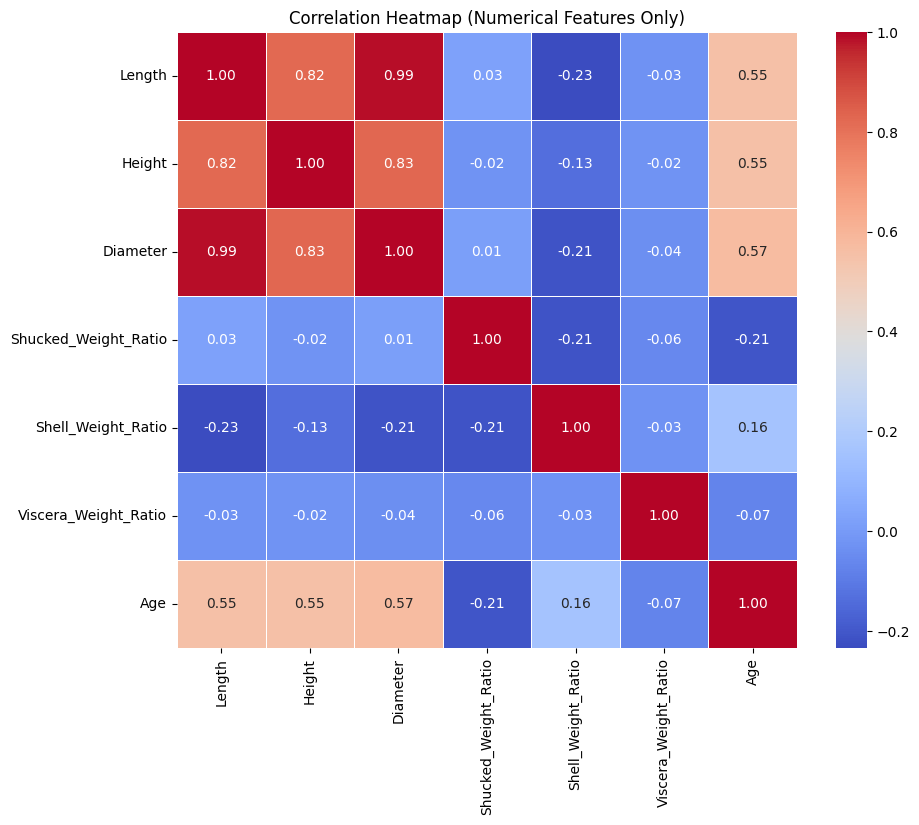

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Select only the numerical columns for the correlation matrix
# This ignores 'Sex' without needing to drop or encode it
numeric_data = X.select_dtypes(include=['number']).join(Y)

# 2. Calculate correlation
corr_matrix = numeric_data.corr()

# 3. Plot the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Correlation Heatmap (Numerical Features Only)')
plt.show()

In [18]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# 1. Select only numerical features from your X dataframe
# (VIF cannot be calculated on the string 'Sex' column)
X_numeric = X.select_dtypes(include=['number'])

# 2. Add a constant (intercept) - VIF calculation requires this to be accurate
X_numeric_with_const = X_numeric.copy()
X_numeric_with_const['intercept'] = 1

# 3. Calculate VIF for each variable
vif_data = pd.DataFrame()
vif_data["Variable"] = X_numeric_with_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_numeric_with_const.values, i) 
                          for i in range(X_numeric_with_const.shape[1])]

# 4. Display the table (excluding the intercept row for clarity)
print(vif_data[vif_data['Variable'] != 'intercept'].sort_values(by="VIF", ascending=False))

               Variable        VIF
2              Diameter  39.784987
0                Length  39.087932
1                Height   3.257585
4    Shell_Weight_Ratio   1.132035
3  Shucked_Weight_Ratio   1.057460
5  Viscera_Weight_Ratio   1.011243


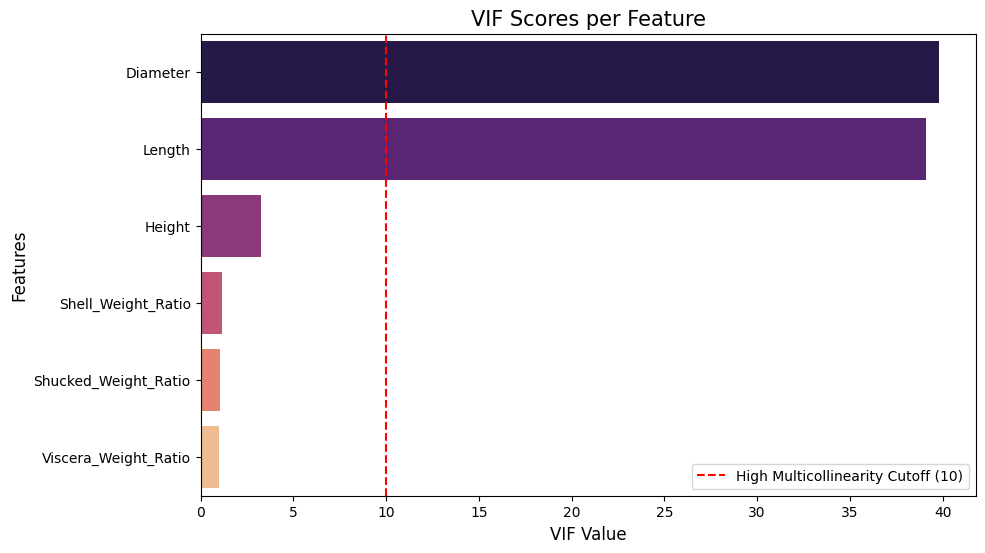

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Prepare numeric data (VIF requires numeric input and an intercept)
X_numeric = X.select_dtypes(include=['number']).copy()
X_numeric['intercept'] = 1

# 2. Calculate VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = X_numeric.columns
vif_data["VIF"] = [variance_inflation_factor(X_numeric.values, i) 
                          for i in range(X_numeric.shape[1])]

# Remove intercept for plotting
vif_plot_data = vif_data[vif_data['Feature'] != 'intercept'].sort_values(by="VIF", ascending=False)

# 3. Create the Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='VIF', y='Feature', data=vif_plot_data, palette='magma')

# Add the cutoff line at 10
plt.axvline(x=10, color='red', linestyle='--', label='High Multicollinearity Cutoff (10)')

# Formatting
plt.title('VIF Scores per Feature', fontsize=15)
plt.xlabel('VIF Value', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.legend()
plt.show()

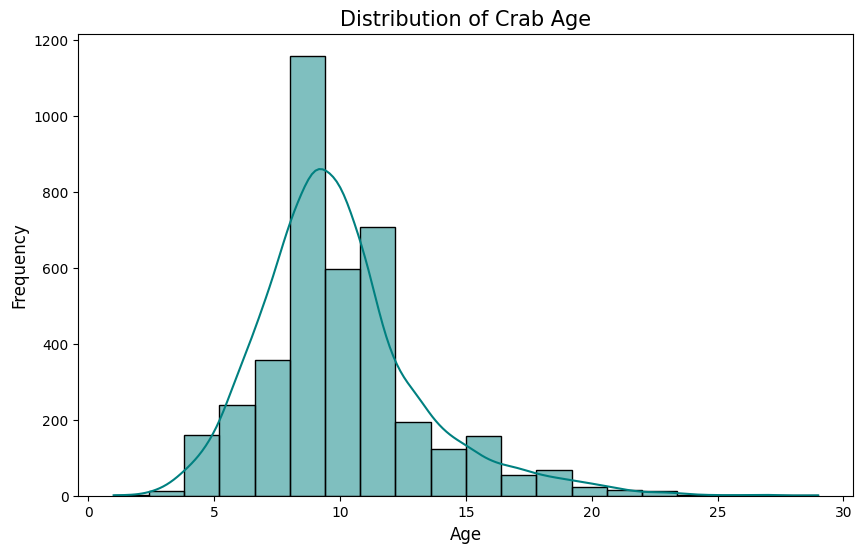

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create the histogram with a density curve
plt.figure(figsize=(10, 6))
sns.histplot(Y, kde=True, color='teal', bins=20)

# Add titles and labels
plt.title('Distribution of Crab Age', fontsize=15)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Show the plot
plt.show()